# Week 6: Toxic Comment Classification - Classical NLP vs DistilBERT

**Objective.** Compare a classical TF-IDF classifier with a modern transformer encoder on the Jigsaw Toxic Comment dataset. Both models use the same stratified held-out test set, and the comparison includes predictive quality, inference latency, and model size.

Run this notebook only after placing Kaggle's `train.csv` at `data/train.csv`. The primary target is the binary `toxic` column.

In [5]:
from pathlib import Path
import json, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from sklearn.model_selection import train_test_split
from sklearn.pipeline import FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             roc_auc_score, ConfusionMatrixDisplay)
from sklearn.utils import resample
import joblib

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DATA_PATH = Path('data/train.csv')
# Google Colab: this opens an upload picker if train.csv is not already available.
if not DATA_PATH.exists():
    try:
        from google.colab import files
        print('Upload Kaggle train.csv when prompted.')
        uploaded = files.upload()
        uploaded_name = next((name for name in uploaded if name.lower() == 'train.csv'), None)
        assert uploaded_name, 'Please upload the file named train.csv from the Jigsaw dataset.'
        DATA_PATH = Path(uploaded_name)
    except ImportError:
        pass
ARTIFACTS = Path('artifacts'); ARTIFACTS.mkdir(exist_ok=True)
# Set to None for the full dataset. 30,000 keeps a classroom run practical.
MAX_TRAIN_ROWS = 30_000
MAX_TEST_ROWS = 5_000
assert DATA_PATH.exists(), f'Missing {DATA_PATH}. Download train.csv from Kaggle and upload/place it there.'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

Using device: cuda


## 1. Load, clean, and split the data
Rows with missing comments are removed. A stratified split preserves the toxic/non-toxic proportion in train and test data. The test set is never used during fitting.

Usable comments: 159,571


,count
toxic,
0,144277
1,15294


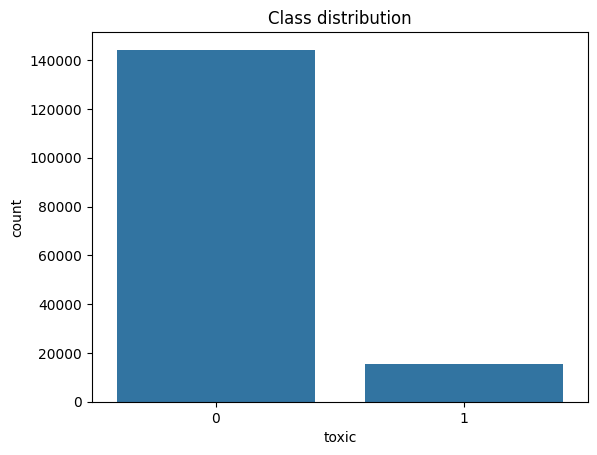

Train: 30,000; held-out test: 5,000; toxic rate in test: 9.58%


In [6]:
raw = pd.read_csv(DATA_PATH)
df = raw[['comment_text', 'toxic']].dropna().copy()
df['comment_text'] = df['comment_text'].astype(str).str.replace(r'\s+', ' ', regex=True).str.strip()
df = df[df['comment_text'].ne('')].reset_index(drop=True)
print(f'Usable comments: {len(df):,}')
display(df['toxic'].value_counts().rename_axis('toxic').to_frame('count'))
sns.countplot(data=df, x='toxic'); plt.title('Class distribution'); plt.show()

train_df, test_df = train_test_split(df, test_size=0.20, stratify=df['toxic'], random_state=SEED)
# A reproducible stratified sample is used only to control teaching/demo runtime.
def stratified_cap(frame, cap):
    if cap is None or len(frame) <= cap: return frame.reset_index(drop=True)
    parts = [g.sample(max(1, round(cap * len(g) / len(frame))), random_state=SEED)
             for _, g in frame.groupby('toxic')]
    return pd.concat(parts, ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)
train_df = stratified_cap(train_df, MAX_TRAIN_ROWS)
test_df = stratified_cap(test_df, MAX_TEST_ROWS)
X_train, y_train = train_df.comment_text.tolist(), train_df.toxic.to_numpy()
X_test, y_test = test_df.comment_text.tolist(), test_df.toxic.to_numpy()
print(f'Train: {len(X_train):,}; held-out test: {len(X_test):,}; toxic rate in test: {y_test.mean():.2%}')

## 2. Shared evaluation and latency measurement
The helper returns accuracy, precision, recall, F1, and ROC-AUC. Latency is measured after a warm-up and reported as the median milliseconds per single comment; this is closer to an online moderation request than batched throughput.

In [7]:
def classification_metrics(y_true, probabilities):
    predicted = (np.asarray(probabilities) >= 0.50).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, predicted, average='binary', zero_division=0)
    return {'accuracy': accuracy_score(y_true, predicted), 'precision': precision,
            'recall': recall, 'f1': f1, 'roc_auc': roc_auc_score(y_true, probabilities)}

def median_single_latency_ms(predict_proba_one, texts, n=200):
    examples = list(texts[:min(n, len(texts))])
    for text in examples[:10]: predict_proba_one(text)  # warm-up
    timings = []
    for text in examples:
        start = time.perf_counter(); predict_proba_one(text); timings.append((time.perf_counter()-start)*1000)
    return float(np.median(timings))

results = {}

## 3. Baseline: word + character TF-IDF with Logistic Regression
Word n-grams capture terms and short phrases; character n-grams make the baseline more resilient to misspellings and obfuscated abusive words. Logistic Regression is a strong, interpretable sparse-text baseline. `class_weight='balanced'` counters the imbalanced label distribution.

In [8]:
tfidf = FeatureUnion([
    ('word', TfidfVectorizer(lowercase=True, strip_accents='unicode', ngram_range=(1, 2), min_df=2, max_df=0.98, sublinear_tf=True, max_features=120_000)),
    ('char', TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), min_df=3, sublinear_tf=True, max_features=80_000))
])
baseline = LogisticRegression(C=2.0, class_weight='balanced', max_iter=1000, solver='liblinear', random_state=SEED)

start = time.perf_counter()
X_train_tfidf = tfidf.fit_transform(X_train)
baseline.fit(X_train_tfidf, y_train)
baseline_train_seconds = time.perf_counter() - start
test_tfidf = tfidf.transform(X_test)
baseline_prob = baseline.predict_proba(test_tfidf)[:, 1]
baseline_path = ARTIFACTS / 'tfidf_logreg.joblib'
joblib.dump({'vectorizer': tfidf, 'classifier': baseline}, baseline_path)

def baseline_one(text): return baseline.predict_proba(tfidf.transform([text]))[0, 1]
results['TF-IDF + Logistic Regression'] = classification_metrics(y_test, baseline_prob)
results['TF-IDF + Logistic Regression'].update({'train_seconds': baseline_train_seconds,
    'latency_ms': median_single_latency_ms(baseline_one, X_test),
    'model_mb': baseline_path.stat().st_size / 1024**2})
pd.Series(results['TF-IDF + Logistic Regression']).round(4)

,0
accuracy,0.9572
precision,0.7721
recall,0.7850
f1,0.7785
roc_auc,0.9747
train_seconds,30.1928
latency_ms,2.6474
model_mb,8.7280


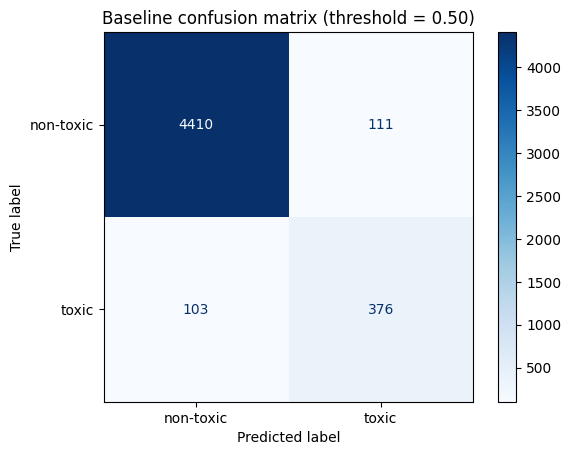

,feature,coefficient
40081,fuck,6.348076
11757,ass,6.080454
91590,shit,5.954684
96138,stupid,4.959698
46623,idiot,4.523345
40617,gay,4.346065
40120,fucking,4.325424
44411,hell,4.166370
60157,moron,4.031117
118349,you,3.934451


In [9]:
ConfusionMatrixDisplay.from_predictions(y_test, baseline_prob >= .50, display_labels=['non-toxic', 'toxic'], cmap='Blues')
plt.title('Baseline confusion matrix (threshold = 0.50)'); plt.show()
# Optional interpretability: coefficients for word features only.
word_features = tfidf.transformer_list[0][1].get_feature_names_out()
word_coefs = baseline.coef_[0][:len(word_features)]
top_toxic = pd.DataFrame({'feature': word_features, 'coefficient': word_coefs}).nlargest(15, 'coefficient')
display(top_toxic)

## 4. Modern approach: fine-tuned DistilBERT
DistilBERT reads subword tokens in context, allowing word order and surrounding language to influence the prediction. It is fine-tuned on the same training split. A GPU is recommended but not required.

In [10]:
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding, Trainer, TrainingArguments

MODEL_NAME = 'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
def make_dataset(frame):
    ds = Dataset.from_pandas(frame[['comment_text', 'toxic']].rename(columns={'toxic': 'labels'}), preserve_index=False)
    return ds.map(lambda batch: tokenizer(batch['comment_text'], truncation=True, max_length=128), batched=True, remove_columns=['comment_text'])
train_ds, test_ds = make_dataset(train_df), make_dataset(test_df)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(DEVICE)
collator = DataCollatorWithPadding(tokenizer=tokenizer)

def transformer_metrics(eval_prediction):
    logits, labels = eval_prediction
    probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()
    return classification_metrics(labels, probs)

args = TrainingArguments(output_dir=str(ARTIFACTS / 'distilbert_checkpoints'),
    learning_rate=2e-5, per_device_train_batch_size=16, per_device_eval_batch_size=32,
    num_train_epochs=2, weight_decay=0.01, eval_strategy='epoch', save_strategy='no',
    logging_strategy='steps', logging_steps=50, report_to='none', fp16=torch.cuda.is_available(), seed=SEED)
trainer = Trainer(model=model, args=args, train_dataset=train_ds, eval_dataset=test_ds,
                  data_collator=collator, compute_metrics=transformer_metrics)
start = time.perf_counter(); trainer.train(); transformer_train_seconds = time.perf_counter() - start

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/30000 [00:00<?, ? examples/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.108869,0.100740,0.966400,0.847875,0.791232,0.818575,0.982143
2,0.073794,0.125529,0.965000,0.853488,0.766180,0.807481,0.980587


In [11]:
prediction = trainer.predict(test_ds)
transformer_prob = torch.softmax(torch.tensor(prediction.predictions), dim=1)[:, 1].numpy()
transformer_dir = ARTIFACTS / 'distilbert_toxic'
trainer.save_model(str(transformer_dir)); tokenizer.save_pretrained(str(transformer_dir))

@torch.inference_mode()
def transformer_one(text):
    encoded = tokenizer(text, return_tensors='pt', truncation=True, max_length=128).to(DEVICE)
    if DEVICE == 'cuda': torch.cuda.synchronize()
    probability = torch.softmax(model(**encoded).logits, dim=1)[0, 1].item()
    if DEVICE == 'cuda': torch.cuda.synchronize()
    return probability

model_bytes = sum(p.stat().st_size for p in transformer_dir.rglob('*') if p.is_file())
results['Fine-tuned DistilBERT'] = classification_metrics(y_test, transformer_prob)
results['Fine-tuned DistilBERT'].update({'train_seconds': transformer_train_seconds,
    'latency_ms': median_single_latency_ms(transformer_one, X_test), 'model_mb': model_bytes / 1024**2})
pd.Series(results['Fine-tuned DistilBERT']).round(4)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

,0
accuracy,0.9650
precision,0.8535
recall,0.7662
f1,0.8075
roc_auc,0.9806
train_seconds,236.6735
latency_ms,16.4044
model_mb,256.1095


## 5. Direct comparison and deployment interpretation
Do not select a model from accuracy alone. Toxicity data are imbalanced, so compare F1/recall too. Then ask whether the quality improvement justifies latency, memory, hardware, operating cost, and maintenance.

,accuracy,precision,recall,f1,roc_auc,median_latency_ms,disk_size_mb,train_seconds
TF-IDF + Logistic Regression,0.9572,0.7721,0.7850,0.7785,0.9747,2.6474,8.7280,30.1928
Fine-tuned DistilBERT,0.9650,0.8535,0.7662,0.8075,0.9806,16.4044,256.1095,236.6735


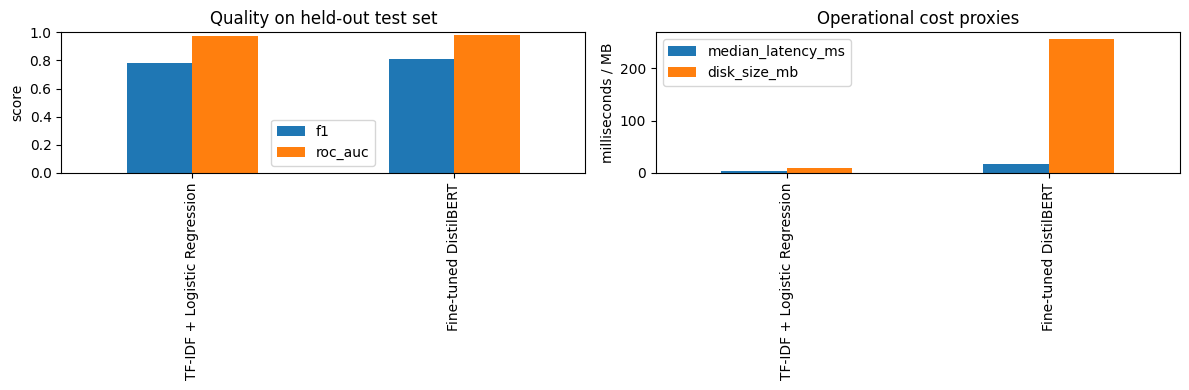

Highest F1: Fine-tuned DistilBERT; lowest online latency: TF-IDF + Logistic Regression.
Copy the displayed values into deployment_memo.md, explain the trade-off, and state a decision appropriate to your deployment assumptions.


In [12]:
comparison = pd.DataFrame(results).T[['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'latency_ms', 'model_mb', 'train_seconds']]
comparison = comparison.rename(columns={'latency_ms': 'median_latency_ms', 'model_mb': 'disk_size_mb'})
display(comparison.round(4))
comparison.to_csv(ARTIFACTS / 'model_comparison.csv')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
comparison[['f1', 'roc_auc']].plot.bar(ax=axes[0], ylim=(0, 1), title='Quality on held-out test set')
comparison[['median_latency_ms', 'disk_size_mb']].plot.bar(ax=axes[1], title='Operational cost proxies')
axes[0].set_ylabel('score'); axes[1].set_ylabel('milliseconds / MB'); plt.tight_layout(); plt.show()

best_f1 = comparison['f1'].idxmax()
fastest = comparison['median_latency_ms'].idxmin()
print(f'Highest F1: {best_f1}; lowest online latency: {fastest}.')
print('Copy the displayed values into deployment_memo.md, explain the trade-off, and state a decision appropriate to your deployment assumptions.')

In [3]:
!unzip -o "train.csv (1).zip" -d .

Archive:  train.csv (1).zip
  inflating: ./train.csv             


In [4]:
import os
os.makedirs('data', exist_ok=True)
os.rename('train.csv', 'data/train.csv')

## 6. Final checklist

- [ ] `data/train.csv` was obtained legally and is excluded from the repository.
- [ ] Both models trained on the exact same training rows and were evaluated on the untouched test rows.
- [ ] The comparison table contains actual run output, not estimated figures.
- [ ] `deployment_memo.md` contains the actual metrics and a decision that covers quality, latency, cost, maintainability, explainability, and safety.
- [ ] Repository name follows the requested `FirstName_LastName_Week6` convention.